This third notebook solves for the ground-state of the He-like systems, by parameterizing the Slater determinant,
$$
\Psi(\boldsymbol{X}_1,\boldsymbol{X}_2,Z_{\rm{eff}}) =\left[ \psi_{1\rm{s}}(\boldsymbol{r}_1,Z_{\rm{eff,1}})\psi_{1\rm{s}}(\boldsymbol{r}_2,Z_{\rm{eff,2}}) +  \psi_{1\rm{s}}(\boldsymbol{r}_1,Z_{\rm{eff,1}})\psi_{1\rm{s}}(\boldsymbol{r}_1,Z_{\rm{eff,2}})\right](1+c r_{12}) \left(\frac{1}{\sqrt{2}}\uparrow_1\downarrow_2 -  \frac{1}{\sqrt{2}}\downarrow_1\uparrow_2 \right)
$$

where the bracketed spin term is a normalized Singlet state, and can effectively be ignored for the calculation of Hamiltonian matrix element. $Z_{\rm{eff},1 (2)}$ paramterize each of the one-electron wavefunctions.

The Hamiltonian for a He-like system is,
$$
\mathcal{H} = -\frac{1}{2} \left(\nabla^2_1 + \nabla^2_2 \right) - \frac{Z}{r_1}- \frac{Z}{r_2} + \frac{1}{r_{12}},
$$
where $Z$ is the charge of the nucleus and not to be confused with $Z_{\rm{eff}}$.  

The $r_{12}$ term directly in the above is _possibe_ to do in spherical coordinates (see notebook 3.5) - but better to do it in different coordinates.

In [11]:
import sympy as sp
sp.init_printing(use_latex='mathjax')
from IPython.display import display
# Define symbolic variables
e, epsilon_0, a = sp.symbols("e epsilon_0 a", positive=True, real=True)
theta2, phi2 = sp.symbols("theta2 phi2", real=True)

psi1 = sp.symbols('psi1')

r1,r2         = sp.symbols('r1 r2',real=True,positive=True)
r12          = sp.Symbol('r_{12}',real=True,positive=True)

phi1,phi2     = sp.symbols('phi1 phi2',real=True)
theta1,theta2 = sp.symbols('theta1 theta2',real=True)


u = sp.symbols('u',real=True,positive=True)
Z_eff1     = sp.symbols('Z_eff1',real=True,positive=True)
Z_eff2     = sp.symbols('Z_eff2',real=True,positive=True)
c          = sp.symbols('c',real=True)


Z         = sp.symbols('Z',real=True,positive=True)
E= sp.symbols('E')
s,t,u        = sp.symbols('s,t,u',real=True)
a,b        = sp.symbols('a,b',real=True)
k,l,gamma        = sp.symbols('k,l, gamma',real=True,nonzero=True,positive=True)

psi = sp.Function('psi')



In [12]:
import sympy as sp
from sympy import symbols, Ynm
# 1. Define standard symbols and your function
r, theta, phi = sp.symbols('r theta phi', positive=True)

def attackSQRT(expr):
    #sympy struggles when sqrts are involved. 
    sqrt_map = {
        root: sp.sqrt(root.args[0].factor()) 
        for root in expr.find(sp.Pow) 
        if root.args[1] == sp.Rational(1, 2)
    }
    
    return expr.subs(sqrt_map)

def sphericalLaplacian(f,r,theta,phi):
    term_r = (1 / r**2) * sp.diff(r**2 * sp.diff(f, r), r)
    term_theta = (1 / (r**2 * sp.sin(theta))) * sp.diff(sp.sin(theta) * sp.diff(f, theta), theta)
    term_phi = (1 / (r**2 * sp.sin(theta)**2)) * sp.diff(f, phi, 2)
    laplacian = term_r + term_theta + term_phi
    sp.simplify(laplacian)
    return laplacian


def oneParticleIntegral(expr, r_var, theta_var, phi_var):
    # Assuming expr uses specific variables, or you can substitute them if needed:
    phiint   = sp.Integral(expr, (phi_var, 0, 2*sp.pi)).simplify()
    print('phi   int complete')
    #print(phiint)
    thetaint = sp.Integral(phiint * sp.sin(theta_var), (theta_var, 0, sp.pi)).simplify()
    
    thetaint = thetaint.expand()
    thetaint = attackSQRT(thetaint)
    thetaint
    
    print('theta int complete')

    display(thetaint)
    #The theta integral in the 2-electron integrals introduces sqrts 
    rint     = sp.Integral(thetaint*r_var*r_var, (r_var, 0, sp.oo)).doit()
    
    display(rint)
    rint = rint.simplify()
    
    print('r     int complete')

    #print(rint)
    #print(rint)
    
    return rint

def twoParticleIntegral(expr):

    oneInt = oneParticleIntegral(expr,   r1, theta1, phi1)
    twoInt = oneParticleIntegral(oneInt, r2, theta2, phi2)
    return twoInt


def twoParticleIntegralHyll(expr):
    
    vol_element = sp.pi ** 2 * u * (s**2 - t**2)
    
    tInt = sp.Integral(expr * vol_element, (t,-u,u) )
    uInt = sp.Integral(tInt, (u,0,s))
    sInt = sp.Integral(uInt, (s,0,sp.oo))
    
    return sInt



In [13]:
Y = Ynm(1, 0, theta, phi)

In [14]:
Y

Ynm(1, 0, θ, φ)

In [15]:
#sphericalLaplacian(r*Y)

In [16]:
Ynm(0, 0, theta, phi).expand(func=True)**4

  1  
─────
    2
16⋅π 

In [17]:
def oneSorbital(r,theta,phi,Zeff):
    
    return 2 * sp.sqrt(Zeff**3) * sp.exp(-Zeff*r) *  Ynm(0, 0, theta, phi).expand(func=True)

In [18]:
#r12 = (sp.sqrt(r1**2 + r2**2 - 2*r1*r2 * sp.cos(theta1)))

In [19]:
oneSorbital(r2,theta2,phi2,Z_eff1)

      3/2  -Z_eff1⋅r₂
Z_eff1   ⋅ℯ          
─────────────────────
         √π          

In [20]:
He_trial_GS = (oneSorbital(r1,theta1,phi1,Z_eff1) * oneSorbital(r2,theta2,phi2,Z_eff2)  + oneSorbital(r1,theta1,phi1,Z_eff2) * oneSorbital(r2,theta2,phi2,Z_eff1)) * (1+c*r12)

In [21]:
He_trial_GS_HYLL = He_trial_GS.subs(r12,u).subs(r1, (s+t)/2).subs(r2, (s-t)/2)
He_trial_GS_HYLL

          ⎛                             ⎛s   t⎞          ⎛s   t⎞               ↪
          ⎜                     -Z_eff1⋅⎜─ + ─⎟  -Z_eff2⋅⎜─ - ─⎟               ↪
          ⎜      3/2       3/2          ⎝2   2⎠          ⎝2   2⎠         3/2   ↪
          ⎜Z_eff1   ⋅Z_eff2   ⋅ℯ               ⋅ℯ                  Z_eff1   ⋅Z ↪
(c⋅u + 1)⋅⎜───────────────────────────────────────────────────── + ─────────── ↪
          ⎝                          π                                         ↪

↪                   ⎛s   t⎞          ⎛s   t⎞⎞
↪           -Z_eff1⋅⎜─ - ─⎟  -Z_eff2⋅⎜─ + ─⎟⎟
↪      3/2          ⎝2   2⎠          ⎝2   2⎠⎟
↪ _eff2   ⋅ℯ               ⋅ℯ               ⎟
↪ ──────────────────────────────────────────⎟
↪                π                          ⎠

In [22]:
He_trial_GS_HYLL.expand()

                         -Z_eff1⋅s   Z_eff1⋅t  -Z_eff2⋅s   -Z_eff2⋅t           ↪
                         ──────────  ────────  ──────────  ──────────          ↪
      3/2       3/2          2          2          2           2               ↪
Z_eff1   ⋅Z_eff2   ⋅c⋅u⋅ℯ          ⋅ℯ        ⋅ℯ          ⋅ℯ             Z_eff1 ↪
───────────────────────────────────────────────────────────────────── + ────── ↪
                                  π                                            ↪

↪                    -Z_eff1⋅s   -Z_eff1⋅t   -Z_eff2⋅s   Z_eff2⋅t              ↪
↪                    ──────────  ──────────  ──────────  ────────              ↪
↪ 3/2       3/2          2           2           2          2             3/2  ↪
↪    ⋅Z_eff2   ⋅c⋅u⋅ℯ          ⋅ℯ          ⋅ℯ          ⋅ℯ           Z_eff1   ⋅ ↪
↪ ─────────────────────────────────────────────────────────────── + ────────── ↪
↪                             π                                                ↪

↪            -Z_eff1⋅s   Z

In [23]:
ee = He_trial_GS_HYLL * He_trial_GS_HYLL
ee = ee.expand()
ee

      3       3  2  2  -Z_eff1⋅s  Z_eff1⋅t  -Z_eff2⋅s  -Z_eff2⋅t           3   ↪
Z_eff1 ⋅Z_eff2 ⋅c ⋅u ⋅ℯ         ⋅ℯ        ⋅ℯ         ⋅ℯ            2⋅Z_eff1 ⋅Z ↪
──────────────────────────────────────────────────────────────── + ─────────── ↪
                                2                                              ↪
                               π                                               ↪

↪      3  2  2  -Z_eff1⋅s  -Z_eff2⋅s         3       3  2  2  -Z_eff1⋅s  -Z_ef ↪
↪ _eff2 ⋅c ⋅u ⋅ℯ         ⋅ℯ            Z_eff1 ⋅Z_eff2 ⋅c ⋅u ⋅ℯ         ⋅ℯ      ↪
↪ ────────────────────────────────── + ─────────────────────────────────────── ↪
↪            2                                                         2       ↪
↪           π                                                         π        ↪

↪ f1⋅t  -Z_eff2⋅s  Z_eff2⋅t           3       3      -Z_eff1⋅s  Z_eff1⋅t  -Z_e ↪
↪     ⋅ℯ         ⋅ℯ           2⋅Z_eff1 ⋅Z_eff2 ⋅c⋅u⋅ℯ         ⋅ℯ        ⋅ℯ     ↪
↪ ────────────────────────

In [24]:
vol_element = 8 * sp.pi ** 2 * u * (s**2 - t**2)
    
tInt = sp.Integral(ee * vol_element, (t,-u,u) )
tInt

u                                                                              ↪
⌠                                                                              ↪
⎮                   ⎛      3       3  2  2  -Z_eff1⋅s  Z_eff1⋅t  -Z_eff2⋅s  -Z ↪
⎮     2   ⎛ 2    2⎞ ⎜Z_eff1 ⋅Z_eff2 ⋅c ⋅u ⋅ℯ         ⋅ℯ        ⋅ℯ         ⋅ℯ   ↪
⎮  8⋅π ⋅u⋅⎝s  - t ⎠⋅⎜───────────────────────────────────────────────────────── ↪
⎮                   ⎜                                2                         ↪
⎮                   ⎝                               π                          ↪
⌡                                                                              ↪
-u                                                                             ↪

↪                                                                              ↪
↪                                                                              ↪
↪ _eff2⋅t           3       3  2  2  -Z_eff1⋅s  -Z_eff2⋅s         3       3  2 ↪
↪           2⋅Z_eff1 ⋅Z_eff

In [25]:
#tInt.doit()

In [26]:
uInt = sp.Integral(tInt, (u,0,s))
sInt = sp.Integral(uInt, (s,0,sp.oo))

In [27]:
trial = (sp.exp( - a * r1 - b*r2) + sp.exp( - b * r1 - a*r2)) * (1 + c * r12)
trial

               ⎛ -a⋅r₁ - b⋅r₂    -a⋅r₂ - b⋅r₁⎞
(c⋅r_{12} + 1)⋅⎝ℯ             + ℯ            ⎠

In [28]:
trial = trial.subs(r12,u).subs(r1, (s+t)/2).subs(r2, (s-t)/2)
trial

          ⎛     ⎛s   t⎞     ⎛s   t⎞        ⎛s   t⎞     ⎛s   t⎞⎞
          ⎜ - a⋅⎜─ - ─⎟ - b⋅⎜─ + ─⎟    - a⋅⎜─ + ─⎟ - b⋅⎜─ - ─⎟⎟
          ⎜     ⎝2   2⎠     ⎝2   2⎠        ⎝2   2⎠     ⎝2   2⎠⎟
(c⋅u + 1)⋅⎝ℯ                        + ℯ                       ⎠

In [29]:
sp.cosh

cosh

In [30]:
trial = trial.subs(a,k+l).subs(b,k-l).expand()
display(trial)

ff = (trial * trial).expand().collect(sp.exp(2*l*t)).collect(sp.exp(-2*l*t))
display(ff)

     -k⋅s  l⋅t        -k⋅s  -l⋅t    -k⋅s  l⋅t    -k⋅s  -l⋅t
c⋅u⋅ℯ    ⋅ℯ    + c⋅u⋅ℯ    ⋅ℯ     + ℯ    ⋅ℯ    + ℯ    ⋅ℯ    

   2  2  -2⋅k⋅s          -2⋅k⋅s   ⎛ 2  2  -2⋅k⋅s          -2⋅k⋅s    -2⋅k⋅s⎞  2 ↪
2⋅c ⋅u ⋅ℯ       + 4⋅c⋅u⋅ℯ       + ⎝c ⋅u ⋅ℯ       + 2⋅c⋅u⋅ℯ       + ℯ      ⎠⋅ℯ  ↪

↪ ⋅l⋅t   ⎛ 2  2  -2⋅k⋅s          -2⋅k⋅s    -2⋅k⋅s⎞  -2⋅l⋅t      -2⋅k⋅s
↪      + ⎝c ⋅u ⋅ℯ       + 2⋅c⋅u⋅ℯ       + ℯ      ⎠⋅ℯ       + 2⋅ℯ      

In [31]:
ff = (trial * trial).expand().collect(sp.exp(-2*k*s)).collect(sp.exp(2*l*t)).collect(sp.exp(-2*l*t)).collect(c**2 * u **2 + 2 *c *u + 1)
ff.subs(sp.exp(2*l*t) + sp.exp(-2*l*t),sp.pi)
ff

⎛   2  2           ⎛ 2⋅l⋅t    -2⋅l⋅t⎞ ⎛ 2  2            ⎞    ⎞  -2⋅k⋅s
⎝2⋅c ⋅u  + 4⋅c⋅u + ⎝ℯ      + ℯ      ⎠⋅⎝c ⋅u  + 2⋅c⋅u + 1⎠ + 2⎠⋅ℯ      

In [32]:
ff = (trial * trial).expand()
ff = ff.subs(sp.exp(2*l*t), sp.cosh(2 * l * t) + sp.sinh(2 * l * t)).expand().simplify()
ff

                       2                
         2 ⎛ 2⋅l⋅t    ⎞   -2⋅k⋅s - 2⋅l⋅t
(c⋅u + 1) ⋅⎝ℯ      + 1⎠ ⋅ℯ              

In [33]:
ff = ff.subs(sp.exp(2*l*t)+1,sp.exp(l*t) * 2 * sp.cosh(l*t)).simplify()
ff

           2  -2⋅k⋅s     2     
4⋅(c⋅u + 1) ⋅ℯ      ⋅cosh (l⋅t)

In [34]:
def twoParticleIntegralHyll(expr):
    
    vol_element = 8 * sp.pi ** 2 * u * (s**2 - t**2)
    
    tInt = sp.Integral( (expr * vol_element).expand(), (t,-u,u) )
    tInt = tInt.doit()
    tInt = tInt.expand().simplify()
    
    uInt = sp.Integral(tInt, (u,0,s)).doit()
    
    sInt = sp.Integral(uInt, (s,0,sp.oo)).doit()
    
    return sInt

In [35]:
innerProduct               = twoParticleIntegralHyll(ff)

repulsion_integral = twoParticleIntegralHyll(ff / u) 

display(repulsion_integral)

⎧   ⎛    2         2            2             2               2          2     ↪
⎪ 2 ⎜10⋅c       5⋅c          5⋅c           5⋅c             5⋅c          c      ↪
⎪π ⋅⎜───── - ────────── - ────────── - ───────────── + ───────────── - ───── - ↪
⎪   ⎜  6      6 ⎛    l⎞    6 ⎛    l⎞               2               2    2  4   ↪
⎪   ⎜ l      l ⋅⎜1 + ─⎟   l ⋅⎜1 - ─⎟      5 ⎛    l⎞       5 ⎛    l⎞    k ⋅l    ↪
⎪   ⎜           ⎝    k⎠      ⎝    k⎠   k⋅l ⋅⎜1 + ─⎟    k⋅l ⋅⎜1 - ─⎟            ↪
⎪   ⎝                                       ⎝    k⎠         ⎝    k⎠            ↪
⎪───────────────────────────────────────────────────────────────────────────── ↪
⎪                                                                              ↪
⎪                                                                              ↪
⎪                     ∞                                                        ↪
⎨                     ⌠                                                        ↪
⎪                     ⎮ ⎛   

In [36]:
repulsion_integral = repulsion_integral.subs(k,l+gamma).subs(gamma, k-l)

In [37]:
coulombIntegral =    twoParticleIntegralHyll(ff * (1/(s+t) + 1/(s-t))*-2*Z )
coulombIntegral = coulombIntegral.subs(k,l+gamma).subs(gamma, k-l)

In [38]:
coulombIntegral

     ⎛        2             2              2               2                2  ↪
 2   ⎜     3⋅c           3⋅c            6⋅c             6⋅c              9⋅c   ↪
π ⋅Z⋅⎜- ─────────── + ─────────── - ───────────── - ───────────── - ────────── ↪
     ⎜            2             2               3               3              ↪
     ⎜   5 ⎛    l⎞     5 ⎛    l⎞       4 ⎛    l⎞       4 ⎛    l⎞     2  3 ⎛    ↪
     ⎜  l ⋅⎜1 + ─⎟    l ⋅⎜1 - ─⎟    k⋅l ⋅⎜1 + ─⎟    k⋅l ⋅⎜1 - ─⎟    k ⋅l ⋅⎜1 + ↪
     ⎝     ⎝    k⎠       ⎝    k⎠         ⎝    k⎠         ⎝    k⎠          ⎝    ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪
                                                                               ↪

↪                2                2                2             2             ↪
↪             9⋅c             12⋅c             12⋅c         144⋅c    8⋅c       ↪
↪ ──── + ────────────── - ─

In [39]:
def two_particle_laplacian(psi):
    """
    Computes (grad_1^2 + grad_2^2) psi(s, t, u) for S-states in Hylleraas coordinates.
    """
    # First derivatives
    ds = sp.diff(psi, s)
    dt = sp.diff(psi, t)
    du = sp.diff(psi, u)
    
    # Second and cross derivatives
    dss = sp.diff(psi, s, 2)
    dtt = sp.diff(psi, t, 2)
    duu = sp.diff(psi, u, 2)
    dsu = sp.diff(psi, s, u)
    dtu = sp.diff(psi, t, u)
    
    # Operator terms
    pure_second = 2 * (dss + dtt + duu)
    radial_u = (4 / u) * du
    cross_su = (4 * s * (u**2 - t**2) / (u * (s**2 - t**2))) * dsu
    cross_tu = (4 * t * (s**2 - u**2) / (u * (s**2 - t**2))) * dtu
    first_s = (8 * s / (s**2 - t**2)) * ds
    first_t = -(8 * t / (s**2 - t**2)) * dt
    
    return sp.simplify(pure_second + radial_u + cross_su + cross_tu + first_s + first_t)

In [40]:
KE_integrand = two_particle_laplacian(trial) * trial

In [41]:
from sympy import S

frac = S(1)/2
KE = twoParticleIntegralHyll(KE_integrand.expand().simplify()) * (-frac)
KE = KE.subs(k,l+gamma).subs(gamma, k-l)

In [42]:
total = (KE + coulombIntegral + repulsion_integral) / innerProduct.subs(k,l+gamma).subs(gamma, k-l)

In [43]:
total

  ⎛     ⎛        2             2              2               2                ↪
  ⎜ 2   ⎜     3⋅c           3⋅c            6⋅c             6⋅c              9⋅ ↪
  ⎜π ⋅Z⋅⎜- ─────────── + ─────────── - ───────────── - ───────────── - ─────── ↪
  ⎜     ⎜            2             2               3               3           ↪
  ⎜     ⎜   5 ⎛    l⎞     5 ⎛    l⎞       4 ⎛    l⎞       4 ⎛    l⎞     2  3 ⎛ ↪
  ⎜     ⎜  l ⋅⎜1 + ─⎟    l ⋅⎜1 - ─⎟    k⋅l ⋅⎜1 + ─⎟    k⋅l ⋅⎜1 - ─⎟    k ⋅l ⋅⎜ ↪
  ⎜     ⎝     ⎝    k⎠       ⎝    k⎠         ⎝    k⎠         ⎝    k⎠          ⎝ ↪
k⋅⎜─────────────────────────────────────────────────────────────────────────── ↪
  ⎜                                                                            ↪
  ⎜                                                                            ↪
  ⎜                                                                            ↪
  ⎝                                                                            ↪
────────────────────────────

In [44]:
hamelement = total.subs(k, (a+b)/2).subs(l, (a-b)/2)

In [45]:
innerProduct

⎧   ⎛         2              2                2                 2              ↪
⎪ 2 ⎜     45⋅c           45⋅c             45⋅c              45⋅c               ↪
⎪π ⋅⎜- ──────────── + ──────────── - ─────────────── - ─────────────── - ───── ↪
⎪   ⎜     7 ⎛    l⎞      7 ⎛    l⎞                 2                 2         ↪
⎪   ⎜  4⋅l ⋅⎜1 + ─⎟   4⋅l ⋅⎜1 - ─⎟        6 ⎛    l⎞         6 ⎛    l⎞       2  ↪
⎪   ⎜       ⎝    k⎠        ⎝    k⎠   4⋅k⋅l ⋅⎜1 + ─⎟    4⋅k⋅l ⋅⎜1 - ─⎟    2⋅k ⋅ ↪
⎪   ⎝                                       ⎝    k⎠           ⎝    k⎠          ↪
⎪───────────────────────────────────────────────────────────────────────────── ↪
⎪                                                                              ↪
⎪                                                                              ↪
⎪                                              ∞                               ↪
⎨                                              ⌠                               ↪
⎪                           

In [46]:
hamelement

        ⎛     ⎛        2                    2                                  ↪
        ⎜ 2   ⎜   144⋅c                 12⋅c                              12⋅c ↪
        ⎜π ⋅Z⋅⎜- ──────── - ────────────────────────────── - ───────────────── ↪
        ⎜     ⎜         5                                5                     ↪
        ⎜     ⎜  ⎛a   b⎞                      ⎛a   b    ⎞                      ↪
        ⎜     ⎜  ⎜─ + ─⎟           2        3 ⎜─ - ─    ⎟           2        3 ↪
        ⎜     ⎜  ⎝2   2⎠    ⎛a   b⎞  ⎛a   b⎞  ⎜2   2    ⎟    ⎛a   b⎞  ⎛a   b⎞  ↪
        ⎜     ⎜             ⎜─ - ─⎟ ⋅⎜─ + ─⎟ ⋅⎜───── + 1⎟    ⎜─ - ─⎟ ⋅⎜─ + ─⎟  ↪
        ⎜     ⎜             ⎝2   2⎠  ⎝2   2⎠  ⎜a   b    ⎟    ⎝2   2⎠  ⎝2   2⎠  ↪
        ⎜     ⎜                               ⎜─ + ─    ⎟                      ↪
⎛a   b⎞ ⎜     ⎝                               ⎝2   2    ⎠                      ↪
⎜─ + ─⎟⋅⎜───────────────────────────────────────────────────────────────────── ↪
⎝2   2⎠ ⎜                   

In [47]:
check = sp.lambdify((Z,a,b,c), hamelement)

In [48]:
check(1,1.07478,0.47758,0.31214)

-0.525918705074052

In [49]:
from scipy.optimize import minimize
def minimizesystem(Z,init=(1.0,0.5,0.3)):

    def energy(params):
        a,b,c = params
        return check(Z,a,b,c)
    
    from scipy.optimize import minimize
    
    res = minimize(energy, x0=init,method='Nelder-Mead')
    print(res.x)
    print(res.fun)
    
    return res.fun, res.x

In [50]:
minimizesystem(1)

[1.07484876 0.477446   0.31251769]
-0.5259187358318553


(np.float64(-0.5259187358318553), array([1.07484876, 0.477446  , 0.31251769]))

In [51]:
minimizesystem(10)

[  10.64957431   10.65627424 -598.19872361]
-inf


<lambdifygenerated-1>:2: RuntimeWarning: divide by zero encountered in scalar divide
  return ((1/2)*a + (1/2)*b)*(pi**2*Z*(-144*c**2/((1/2)*a + (1/2)*b)**5 - 12*c**2/(((1/2)*a - 1/2*b)**2*((1/2)*a + (1/2)*b)**3*(((1/2)*a - 1/2*b)/((1/2)*a + (1/2)*b) + 1)**5) - 12*c**2/(((1/2)*a - 1/2*b)**2*((1/2)*a + (1/2)*b)**3*(-((1/2)*a - 1/2*b)/((1/2)*a + (1/2)*b) + 1)**5) - 9*c**2/(((1/2)*a - 1/2*b)**3*((1/2)*a + (1/2)*b)**2*(((1/2)*a - 1/2*b)/((1/2)*a + (1/2)*b) + 1)**4) + 9*c**2/(((1/2)*a - 1/2*b)**3*((1/2)*a + (1/2)*b)**2*(-((1/2)*a - 1/2*b)/((1/2)*a + (1/2)*b) + 1)**4) - 6*c**2/(((1/2)*a - 1/2*b)**4*((1/2)*a + (1/2)*b)*(((1/2)*a - 1/2*b)/((1/2)*a + (1/2)*b) + 1)**3) - 6*c**2/(((1/2)*a - 1/2*b)**4*((1/2)*a + (1/2)*b)*(-((1/2)*a - 1/2*b)/((1/2)*a + (1/2)*b) + 1)**3) - 3*c**2/(((1/2)*a - 1/2*b)**5*(((1/2)*a - 1/2*b)/((1/2)*a + (1/2)*b) + 1)**2) + 3*c**2/(((1/2)*a - 1/2*b)**5*(-((1/2)*a - 1/2*b)/((1/2)*a + (1/2)*b) + 1)**2) - 120*c/((1/2)*a + (1/2)*b)**4 - 12*c/(((1/2)*a - 1/2*b)**2*((1/2)*a + (1

(np.float64(-inf), array([  10.64957431,   10.65627424, -598.19872361]))

In [52]:
import numpy as np 
import matplotlib.pyplot as plt 

In [53]:
zz = np.arange(1, 30, 1,dtype=int)

In [54]:
ee = np.zeros_like(zz).astype(float)
init = (1.0,0.5,0.3)
for ii in range(0,len(zz)):
    print(zz[ii])
    ee[ii],init = minimizesystem(zz[ii],init)

1
[1.07484876 0.477446   0.31251769]
-0.5259187358318553
2
[2.20845533 1.4362006  0.29272905]
-2.9014197295412076
3
[3.2994454  2.36184238 0.27698803]
-7.277173734945973
4
[4.37443008 3.29339082 0.26881628]
-13.652545480246669
5
[5.43991515 4.23123285 0.26386366]
-22.02775927840992
6
[6.49891202 5.17418219 0.260527  ]
-32.40289659146698
7
[7.5529279  6.12148297 0.25816925]
-44.777991752510495
8
[8.60324931 7.07205371 0.25637841]
-59.15306140403795
9
[9.65037958 8.02558479 0.25501279]
-75.52811450997756
10
[10.69491436  8.98157856  0.25390824]
-93.90315630011152
11
[11.73711862  9.9397678   0.25300499]
-114.27819002184818
12
[12.77760402 10.89959689  0.25225141]
-136.65321779633277
13
[13.8163743  11.86104547  0.25160024]
-161.02824105927067
14
[14.85364932 12.82399454  0.25107917]
-187.40326082611804
15
[15.8897537  13.78812048  0.25060777]
-215.77827782790837
16
[16.92430479 14.75381579  0.2501893 ]
-246.15329259708568
17
[17.95770328 15.72040567  0.24983275]
-278.52830555974015
18
[1

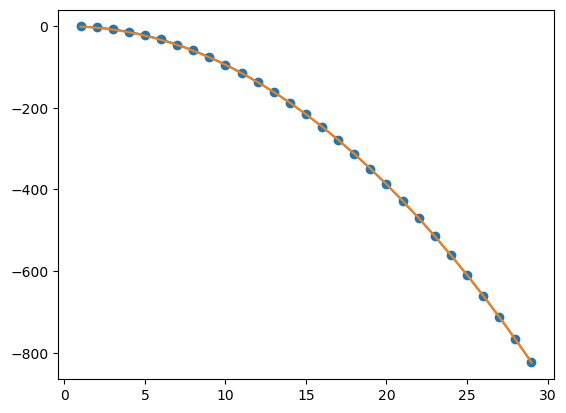

In [55]:
plt.plot(zz,ee,'o-')
from scipy.optimize import curve_fit
def func_powerlaw(x, m, c):
    return x**m * c

sol1 = curve_fit(func_powerlaw, zz, -ee, maxfev=2000 )

plt.plot(zz, -func_powerlaw(zz,*sol1[0]))

#plt.yscale('log')
#plt.xscale('log')